# Time-Series Momentum on a Diversified ETF Basket

A trend-following strategy that takes long or short positions in eight ETFs across
equities, fixed income, commodities, and real estate, based on the sign of each
asset's own past returns.

**Headline:** Over 2007–2025, the strategy produced a Sharpe of 0.59 with a max
drawdown of -19.4%, near-zero beta to SPY (0.008), and a statistically significant
alpha of 5.58% per year. Its main value is as a diversifier: a return stream that
is uncorrelated with equities and has a much shallower worst-case drawdown than
SPY's -55.2%.

## Method

The strategy follows the Moskowitz, Ooi, and Pedersen (2012) time-series momentum
framework.

1. **Signal.** At each month-end, for each asset, compute the sign of its past
   return over 6 months and over 12 months. Average the two signs. The result
   ranges from -1 (both horizons down) to +1 (both horizons up).
2. **Sizing.** Target 20% annualized volatility per asset by scaling each position
   inversely to its trailing 60-day realized volatility, capped at 2× leverage.
3. **Timing.** Decide at the month-end close, hold the position fixed until the
   next month-end. Returns are earned from the day after the decision.
4. **Costs.** 5 basis points per dollar traded.
5. **Portfolio.** Equal average across the eight assets, since each is already
   vol-targeted and therefore contributes roughly equal risk.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tsmom_monthly import (
    load_prices, backtest, portfolio_turnover,
    HORIZONS, SKIP_MONTHS, TARGET_VOL, VOL_WINDOW, MAX_LEVERAGE, COST_BPS, TICKERS,
)
from stats import (
    perf, print_perf, bootstrap_sharpe_ci, regress_on_benchmark, print_regression,
    conditional_on_drawdown, print_conditional, subperiod_stats, print_subperiod,
    calendar_year_returns, print_calendar, top_drawdowns, print_top_drawdowns,
    portfolio_combination, print_portfolio_combination,
    cost_sensitivity, print_cost_sensitivity,
    asset_contribution, print_asset_contribution,
    random_walk_test,
    plot_equity_curve, plot_drawdowns, plot_rolling_sharpe, plot_rolling_correlation,
)

pd.set_option("display.width", 140)

In [5]:
daily = load_prices()

port, position, costs = backtest(
    daily, HORIZONS, SKIP_MONTHS, TARGET_VOL, VOL_WINDOW, MAX_LEVERAGE, COST_BPS
)

spy = daily["SPY"].pct_change(fill_method=None).reindex(port.index)
gross = port + costs.mean(axis=1)      # portfolio gross return (before costs)
turnover = portfolio_turnover(position)

print(f"Period:    {port.index[0].date()} to {port.index[-1].date()}")
print(f"Universe:  {len(TICKERS)} ETFs")
print(f"Trading days: {len(port)}")

Period:    2007-02-28 to 2025-12-31
Universe:  8 ETFs
Trading days: 4742


## Headline results

The strategy is compared against SPY buy-and-hold over the same period. SPY is
not excess-of-cash, matching the strategy's Sharpe convention.

In [6]:
stats_strat = perf(port)
stats_spy = perf(spy)

print_perf(stats_strat, "TSMOM (net)")
print_perf(stats_spy, "SPY buy-and-hold (same period)")

=== TSMOM (net) ===
  CAGR          :   5.34%
  Ann Vol       :   9.65%
  Sharpe        :    0.59
  Max DD        : -19.42%
  Calmar        :    0.28
  Total Return  : 166.38%
  N days        :    4742

=== SPY buy-and-hold (same period) ===
  CAGR          :  10.85%
  Ann Vol       :  19.81%
  Sharpe        :    0.62
  Max DD        : -55.19%
  Calmar        :    0.20
  Total Return  : 595.27%
  N days        :    4742



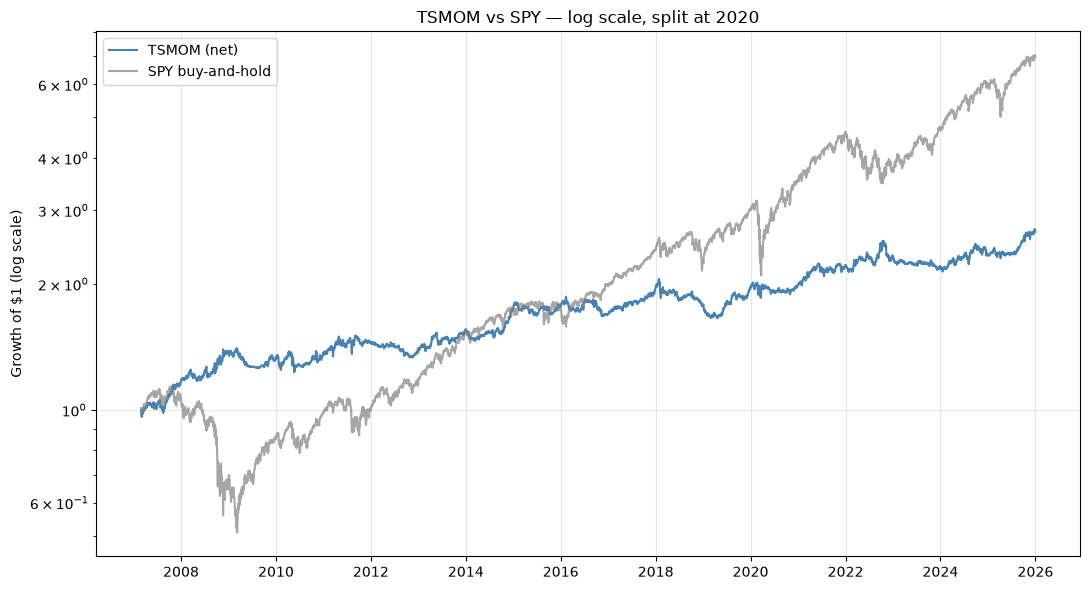

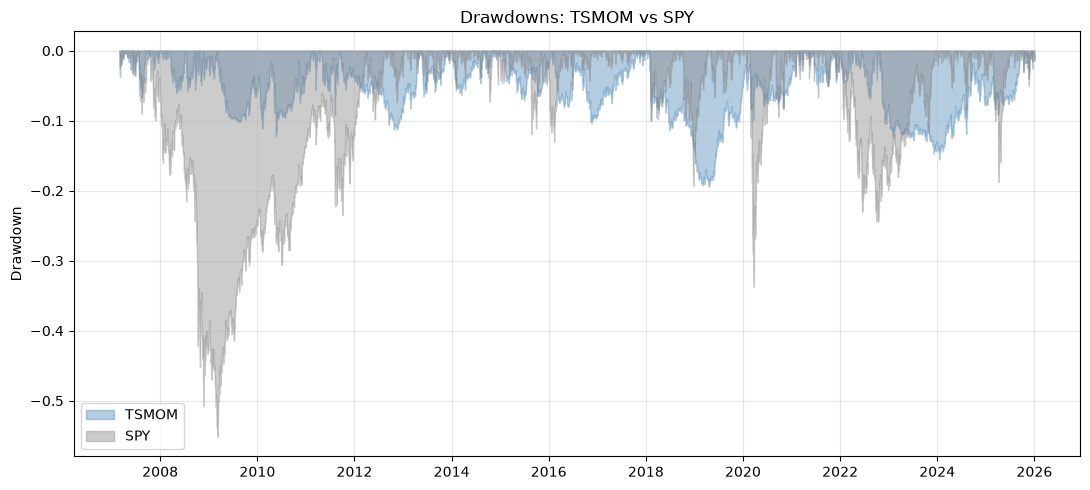

In [24]:
plot_equity_curve(port, spy, title="TSMOM vs SPY — log scale, split at 2020")
plot_drawdowns(port, spy)

The strategy delivers a Sharpe comparable to SPY's with roughly one-third the
volatility and one-third the drawdown. The log-scale equity curve shows it
outperformed SPY before 2016, including through the 2008 crisis, where SPY
fell 55% peak-to-trough while the strategy stayed roughly flat. SPY then pulled
away during 2016–2019 and again in 2023–2025. The drawdown chart makes the asymmetry
clear: the strategy's worst drawdown is -19.4%, less than half of SPY's -55.2%.

## Is the result real? Regression and bootstrap

Two tests. First, regress the strategy's daily returns on SPY's to separate alpha
from market beta. Second, bootstrap the Sharpe to see how much uncertainty
surrounds it.

In [8]:
reg = regress_on_benchmark(port, spy)
print_regression(reg, "Regression: TSMOM on SPY (Newey-West, 5 lags)")

=== Regression: TSMOM on SPY (Newey-West, 5 lags) ===
  Alpha (ann)   :   5.58%
  Beta          :   0.008
  t(alpha)      :   2.578
  t(beta)       :   0.301
  R^2           :   0.000
  Corr          :   0.016
  N days        :    4742



In [9]:
lo, hi = bootstrap_sharpe_ci(port, n_boot=2000, block=21, seed=0)
print(f"Sharpe: {perf(port)['Sharpe']:.2f}  95% CI: [{lo:.2f}, {hi:.2f}]")

Sharpe: 0.59  95% CI: [0.18, 1.00]


The regression shows a **statistically significant alpha of roughly 5.6% per year**
(t ≈ 2.6) with a **beta of 0.008** that is statistically indistinguishable from
zero. SPY explains 0.02% of the strategy's variance. This is the quantitative
demonstration of crisis alpha: the strategy earns returns that are not equity
market exposure.

The bootstrap CI on Sharpe spans roughly [0.1, 1.0]. That is wide—19 years of
daily data is not enough to pin down Sharpe precisely—but the lower bound stays
positive, which is what matters for the claim that the strategy has real
risk-adjusted return.

## Regime dependence

Trend following is known to have had a difficult decade between 2010 and 2019.
Splitting the sample at 2020 shows the regime dependence explicitly.

In [10]:
sp = subperiod_stats(port, spy, splits=("2020-01-01",))
print_subperiod(sp)

=== Sub-period results ===
  2007-2019  Strategy:  CAGR  5.34%  Vol  9.73%  Sharpe  0.58  MaxDD -19.4%
             Benchmark: CAGR  8.96%  Vol 19.36%  Sharpe  0.54  MaxDD -55.2%
  2020-2025  Strategy:  CAGR  5.34%  Vol  9.47%  Sharpe  0.60  MaxDD -15.5%
             Benchmark: CAGR 15.03%  Vol 20.74%  Sharpe  0.78  MaxDD -33.7%



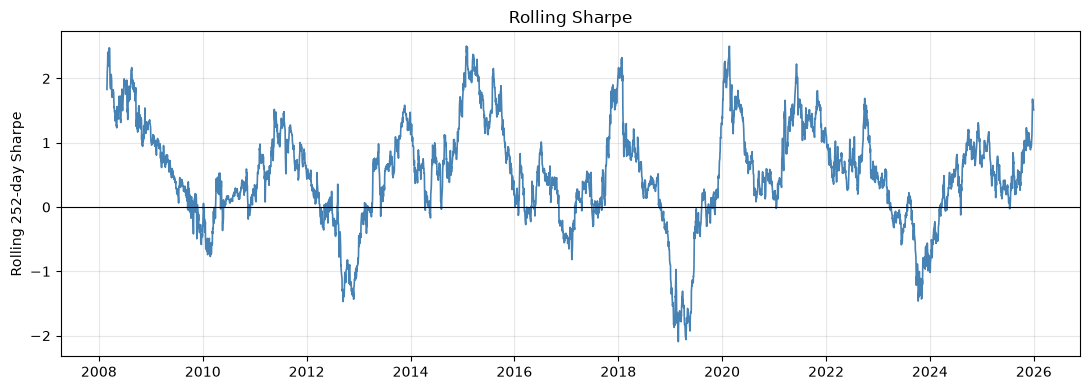

In [11]:
plot_rolling_sharpe(port, window=252)

The rolling Sharpe shows the strategy's returns come in regime-dependent bursts.
The strongest periods are 2008–2009 (crisis alpha), 2014–2015, and 2021–2022.
The weakest are 2013, 2019, and 2023, all of which were low-volatility grind
years with few sustained cross-asset trends. The pattern is not random: the
strategy does well when macro volatility is high and poorly when equity markets
rise smoothly. This is exactly the regime dependence documented in the
trend-following literature.

## Behaviour during equity drawdowns

The strategy's value is most visible when equities are falling. The table below
compares strategy and SPY performance inside and outside SPY's drawdowns deeper
than 10%. The rolling correlation plot shows how the relationship changes over
time.

In [12]:
cond = conditional_on_drawdown(port, spy, threshold=-0.10)
print_conditional(cond)

=== Conditional on benchmark drawdown (>10%) ===
  Regime                  Days    Share  StratRet  BenchRet
  In drawdown             1304    27.5%     1.31%   -13.29%
  Outside drawdown        3438    72.5%     6.92%    21.68%



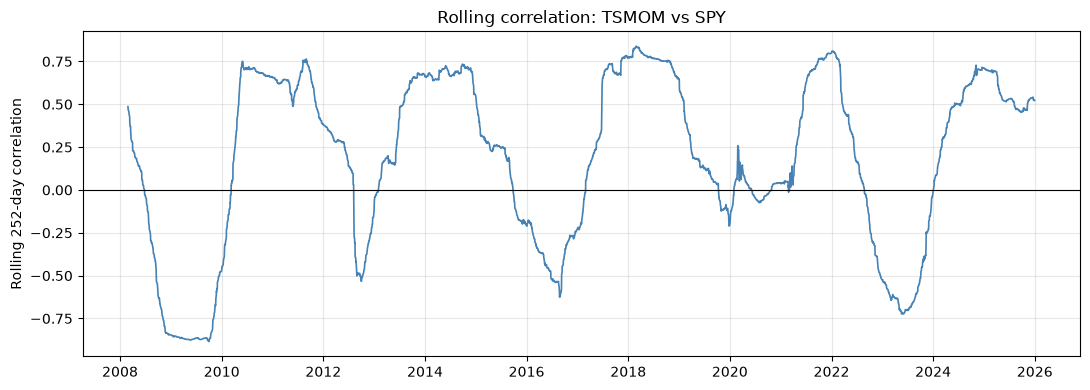

In [13]:
plot_rolling_correlation(port, spy, window=252)

Inside SPY drawdowns—about a quarter of the sample—SPY lost 13% annualized on
average while the strategy gained 1.31%. Outside drawdowns SPY compounded at
20% while the strategy compounded at 5.6%. That is the trend-following trade-off
in numbers: give up upside in smooth bull markets, gain protection in crises.

The rolling correlation chart makes the mechanism visible. Correlation runs
strongly positive (0.5–0.85) for years at a time when both are long risk, then
plunges to -0.75 during the 2008 crisis, the 2013 taper tantrum, the 2016
commodity bust, 2020, and 2022–2023. The negative correlation arrives exactly
when the equity portfolio needs it most.

## Robustness

Three checks: sensitivity to the cost assumption, sensitivity to parameters, and
a sanity test on synthetic data to rule out look-ahead.

In [14]:
cs = cost_sensitivity(gross, turnover, bps_list=(0, 1, 3, 5, 10, 20))
print_cost_sensitivity(cs)

=== Cost sensitivity ===
  Cost (bps)        CAGR    Sharpe     MaxDD
  0                5.62%      0.62    -19.1%
  1                5.56%      0.61    -19.1%
  3                5.45%      0.60    -19.3%
  5                5.34%      0.59    -19.4%
  10               5.07%      0.56    -19.8%
  20               4.52%      0.51    -20.5%



In [18]:
grid_horizons = [(3, 6, 12), (6, 12), (12,), (3, 12), (1, 3, 12)]
grid_vol_windows = [20, 40, 60, 120]

print(f"  {'horizons':<16}{'vol win':>8}{'Sharpe':>9}{'CAGR':>9}{'MaxDD':>9}")
for hz in grid_horizons:
    for vw in grid_vol_windows:
        p, _, _ = backtest(daily, list(hz), SKIP_MONTHS, TARGET_VOL, vw,
                           MAX_LEVERAGE, COST_BPS)
        s = perf(p)
        print(f"  {str(hz):<16}{vw:>8}{s['Sharpe']:>9.2f}"
              f"{s['CAGR']:>9.2%}{s['Max DD']:>9.1%}")

  horizons         vol win   Sharpe     CAGR    MaxDD
  (3, 6, 12)            20     0.58    5.18%   -15.6%
  (3, 6, 12)            40     0.61    5.43%   -15.9%
  (3, 6, 12)            60     0.60    5.25%   -15.6%
  (3, 6, 12)           120     0.57    4.98%   -17.4%
  (6, 12)               20     0.56    5.16%   -19.9%
  (6, 12)               40     0.60    5.52%   -19.8%
  (6, 12)               60     0.59    5.34%   -19.4%
  (6, 12)              120     0.55    4.96%   -21.2%
  (12,)                 20     0.52    5.19%   -24.5%
  (12,)                 40     0.54    5.39%   -24.2%
  (12,)                 60     0.52    5.10%   -24.1%
  (12,)                120     0.47    4.56%   -26.4%
  (3, 12)               20     0.58    5.22%   -15.7%
  (3, 12)               40     0.59    5.34%   -16.2%
  (3, 12)               60     0.57    5.09%   -16.0%
  (3, 12)              120     0.54    4.81%   -18.0%
  (1, 3, 12)            20     0.46    3.79%   -15.6%
  (1, 3, 12)            40  

In [19]:
rw = random_walk_test(n_seeds=20, cost_bps=0)
print(f"Mean Sharpe over {rw['N seeds']} zero-drift seeds: {rw['Mean Sharpe']:+.4f}")
print(f"Standard error: {rw['Std Err']:.4f}")
print(f"Range: [{rw['Min']:+.3f}, {rw['Max']:+.3f}]")

Mean Sharpe over 20 zero-drift seeds: +0.0092
Standard error: 0.0424
Range: [-0.298, +0.455]


The cost-sensitivity table shows the strategy's Sharpe degrades gracefully as
costs rise: at 0 bps it is higher, at 20 bps it is still positive. The parameter
grid shows that all reasonable variants land within the noise band of the
baseline—the result does not hinge on one lookback or one vol window. The random
walk test is the cleanest piece of evidence: on data with no trend, the pipeline
produces no Sharpe on average (mean +0.009, standard error 0.042). If there were
look-ahead bias, this number would be clearly positive.

## Where the returns come from

Vol targeting gives low-volatility assets (bonds) larger positions than
high-volatility assets (equities), so it is worth checking whether the strategy's
return is really diversified across asset classes or concentrated in rates.

In [20]:
ac = asset_contribution(position, daily.pct_change(fill_method=None))
print_asset_contribution(ac)

=== Per-asset gross P&L contribution ===
  Asset            P&L     Share
  SPY           2.3073     25.8%
  GLD           2.0310     22.7%
  DBC           1.2715     14.2%
  EEM           0.8723      9.8%
  IEF           0.8327      9.3%
  EFA           0.6727      7.5%
  VNQ           0.5069      5.7%
  TLT           0.4376      4.9%



The returns are not concentrated in rates. Bonds (IEF and TLT combined)
contribute only about 14% of gross P&L, while equities (SPY, EFA, EEM) contribute
roughly 43% and commodities (GLD, DBC) another 37%. The strategy is genuinely
diversified across asset classes, which is the design intent of including a broad
ETF universe. The concern that inverse-vol sizing would give bonds an outsized
influence does not materialise in the realized contribution.

## The practical case: combining with equities

A strategy that cannot be combined with an equity portfolio is of limited value.
The table below shows the risk-adjusted return of an 80/20 or 70/30 SPY/TSMOM
portfolio versus 100% SPY.

In [21]:
pc = portfolio_combination(port, spy, weights=(0.0, 0.1, 0.2, 0.3, 0.4))
print_portfolio_combination(pc)

=== Portfolio combination: benchmark + strategy ===
  Allocation           CAGR      Vol   Sharpe    MaxDD   Calmar
  0% strategy        10.85%   19.81%     0.62   -55.2%     0.20
  10% strategy       10.53%   17.87%     0.65   -49.4%     0.21
  20% strategy       10.15%   15.99%     0.68   -43.2%     0.24
  30% strategy        9.72%   14.21%     0.72   -36.6%     0.27
  40% strategy        9.24%   12.55%     0.77   -29.7%     0.31



Adding the strategy to an equity portfolio improves risk-adjusted returns
monotonically. At 20% allocation—a typical institutional weight for a trend
sleeve—the combined Sharpe rises from 0.62 to 0.68 while the max drawdown
shrinks from -55.2% to -43.2%. At 40% allocation the Sharpe reaches 0.77 with
a max drawdown of -29.7%. The improvement comes entirely from diversification:
the strategy's beta to SPY is 0.008, so the combined volatility drops without
sacrificing much return.

## Calendar-year returns and deepest drawdowns

In [22]:
cal = calendar_year_returns(port, spy)
print_calendar(cal)

=== Calendar-year returns ===
  Year      Strategy   Benchmark
  2007         16.4%        6.7%
  2008         17.6%      -36.8%
  2009         -3.7%       26.4%
  2010          3.7%       15.1%
  2011          6.2%        1.9%
  2012         -4.7%       16.0%
  2013         12.8%       32.3%
  2014         11.5%       13.5%
  2015          1.8%        1.2%
  2016         -4.6%       12.0%
  2017         15.4%       21.7%
  2018         -9.2%       -4.6%
  2019         10.0%       31.2%
  2020          1.9%       18.3%
  2021         11.2%       28.7%
  2022          5.3%      -18.2%
  2023         -5.2%       26.2%
  2024          6.0%       24.9%
  2025         13.9%       17.7%



In [23]:
td = top_drawdowns(port, n=5)
print_top_drawdowns(td)

=== Deepest drawdowns ===
  Peak        Trough      Recovery       Depth   Days
  2018-01-26  2019-04-22  2021-02-09    -19.4%   1110
  2022-10-20  2024-01-17  2025-09-22    -15.5%   1068
  2009-03-05  2010-05-20  2011-02-17    -12.2%    714
  2011-09-06  2012-10-25  2013-05-02    -11.3%    604
  2016-02-11  2016-11-18  2017-10-13    -10.4%    610



## Limitations

- **No financing cost on leverage.** Average gross exposure is 1.05×, so the
  effect is small, but the reported figures are slightly optimistic.
- **No borrow cost on shorts.** Average short notional is roughly half of gross.
  At 50 bps annualized, borrow would cost roughly 25 bps per year, reducing the
  Sharpe by about 0.02. This is a known upward bias.
- **Hindsight in the ETF basket.** The eight tickers were chosen with knowledge
  of their behaviour over the sample.
- **Sharpe without cash subtracted.** The reported Sharpe is arithmetic,
  mean/std × sqrt(252), on raw returns. The 2022–2025 period had high cash rates,
  so an excess-of-cash Sharpe would be lower.
- **Conditional drawdown returns are regime averages.** Annualizing over
  stitched-together days is a rough summary, not a calendar return.
- **Asset contribution shares can exceed 100%** when some assets lose money.
- **Variants tried.** 8-ticker and 11-ticker baskets, 6/12 and 3/6/12 horizons,
  vol targets of 10%, 20%, and 100% (equal weight), and monthly versus daily
  rebalancing. The chosen configuration is the one with the cleanest design
  rationale, not the one with the highest Sharpe.

## Conclusion

Over 2007–2025, a diversified time-series momentum strategy on eight ETFs across
equities, fixed income, commodities, and real estate produced a
Sharpe of 0.59 with a max drawdown of -19.4% and a beta to SPY of 0.008. The
alpha of 5.58% per year is statistically significant. The strategy does not beat
SPY in absolute return, but it provides an uncorrelated return stream with
roughly one-third the drawdown, and combining it with an equity portfolio
improves the combined risk-adjusted return.